<a href="https://colab.research.google.com/github/carpinetti/2025A-CPGINV-HPC-0012/blob/main/HandsOn01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Instala depêndencias:
* qiskit - É o "motor" principal. É a biblioteca da IBM que permite criar, simular e rodar programas em computadores quânticos usando a linguagem Python.
* qiskit-aer: É o nosso simulador quântico. Rodar programas em um computador quântico real da IBM pode exigir entrar em filas de espera. O Aer permite que o nosso próprio computador clássico (ou servidor) simule instantaneamente como o circuito vai se comportar.
* pylatexenc - Nosso tradutor de símbolos. Ele serve apenas para que símbolos matemáticos (como o $\pi$ ou letras gregas) apareçam desenhados corretamente nos diagramas, deixando o visual profissional.
* matplotlib: O "desenhista". É a biblioteca padrão do Python para gerar gráficos. O Qiskit a utiliza para transformar o código do circuito em uma imagem colorida e fácil de entender.

In [1]:
!pip install qiskit qiskit-aer pylatexenc matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 8.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 80.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 71.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 59.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.9 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=d053a5366110ec6828dcd70000aa21e5595625f5e5ee1d8fd0f12de50debdaf4
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


# Circuito quântico com 1 qubit

### Objetivo:
Demonstrar a evolução do estado de um único qubit por meio da aplicação sequencial de portas quânticas de superposição, fase, operação Pauli e rotações.

### Estado inicial:
Todo qubit em Qiskit é inicializado, por padrão, no estado |0⟩.

Neste circuito, o qubit passa pelas seguintes transformações:
1. H       -> cria superposição equiprovável;
2. S       -> altera a fase relativa do componente |1⟩;
3. Y       -> aplica a porta Pauli-Y, afetando estado e fase;
4. Rx(π/4) -> rotaciona o estado em 45° ao redor do eixo X;
5. Ry(π)   -> rotaciona o estado em 180° ao redor do eixo Y.

---

# Circuito B com dois qubits

### Objetivo:
Demonstrar operações em um sistema de dois qubits, incluindo:

1. inversão de estado com porta Pauli-X;
2. criação de superposição com Hadamard;
3. criação de emaranhamento com CNOT;
4. transformação de base com uma nova Hadamard;
5. rotação Ry(π) aplicada ao segundo qubit.

### Estado inicial:
Como o circuito possui 2 qubits, o estado inicial padrão é |00⟩.
### Observação importante:
Na explicação conceitual, é comum escrever os estados como |q0 q1⟩.

Porém, internamente e ao exibir resultados, o Qiskit adota convenções de ordenação que podem parecer invertidas, especialmente em medições.

Por isso, ao interpretar resultados, é importante observar a ordem dos qubits no circuito.

---

Circuito A:


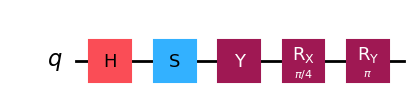

Circuito B:


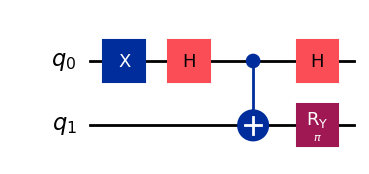

Esfera de bloch:


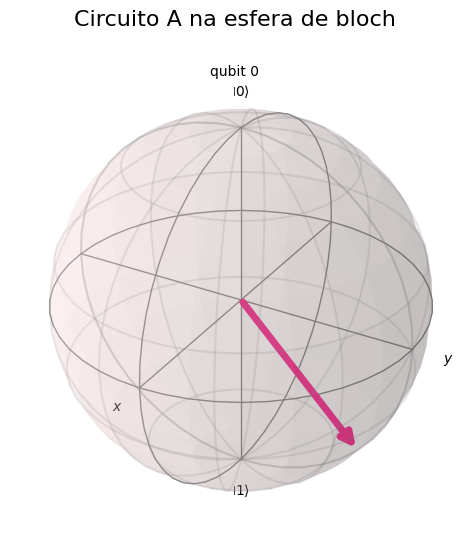

In [10]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
from math import pi
import matplotlib.pyplot as plt
%matplotlib inline

# 1. Cria um circuito quântico "A" com 1 qubit
qcA = QuantumCircuit(1)

# Aplica a porta Hadamard no qubit 0.
# Após essa operação, se o qubit fosse medido imediatamente,
# haveria 50% de probabilidade para |0⟩ e 50% para |1⟩.
qcA.h(0)

# Aplica a porta S no qubit 0.
# A porta S é uma porta de fase.
# Ela mantém |0⟩ inalterado e adiciona uma fase i ao estado |1⟩:
# Essa operação não altera diretamente as probabilidades de medição,
# mas altera a fase relativa entre os componentes do estado.
qcA.s(0)

# Aplica a porta Pauli-Y no qubit 0.
# A porta Y combina inversão de estado com alteração de fase:
# Essa porta atua simultaneamente sobre as amplitudes e as fases.
qcA.y(0)

# Aplica uma rotação Rx(π/4) no qubit 0.
# A porta Rx(θ) representa uma rotação do estado quântico em torno
# do eixo X da esfera de Bloch.
qcA.rx(pi/4, 0)

# Aplica uma rotação Ry(π) no qubit 0.
# A porta Ry(θ) representa uma rotação em torno do eixo Y da esfera de Bloch.
# Para θ = π, a porta Ry tem comportamento semelhante a uma inversão
# entre |0⟩ e |1⟩, mas com alteração de sinal em uma das componentes.
qcA.ry(pi, 0)

# ============================================================
# Circuito B - Circuito quântico de dois qubits com superposição,
# emaranhamento, transformação de base e rotação Ry
# ============================================================

qcB = QuantumCircuit(2)

# Aplica a porta Pauli-X no qubit 0.
# A porta X funciona como um NOT quântico:
# transforma |0⟩ em |1⟩ e |1⟩ em |0⟩.
# Estado inicial: |00⟩
# Após X(0):     |10⟩, considerando a leitura conceitual |q0 q1⟩.

qcB.x(0)
# Aplica a porta Hadamard no qubit 0.
# A porta H coloca o qubit em superposição.
# Como q0 estava em |1⟩, temos:
# H|1⟩ = (|0⟩ - |1⟩) / √2
# O sistema passa a estar em uma combinação linear dos estados |00⟩ e |10⟩.
qcB.h(0)

# Aplica uma porta CNOT com q0 como controle e q1 como alvo.
# Se q0 = 1, a porta X é aplicada em q1.
# Se q0 = 0, q1 permanece inalterado.
#
# Como q0 está em superposição, a CNOT cria correlação quântica
# entre os dois qubits, resultando em um estado emaranhado:
#
# (|00⟩ - |11⟩) / √2
#
# Esse estado é equivalente ao estado de Bell Φ⁻.
qcB.cx(0, 1)         # Apply CNOT (control = q0, target = q1)

# Aplica novamente a porta Hadamard no qubit 0.
# Essa operação altera a base de q0 e transforma o estado emaranhado
# em uma nova combinação linear envolvendo os quatro estados da base:
# |00⟩, |01⟩, |10⟩ e |11⟩.
#
# Após essa operação, todos os estados passam a ter amplitudes
# de mesmo módulo, mas com fases relativas diferentes.
qcB.h(0)

# Aplica uma rotação Ry(π) no qubit 1.
# A porta Ry representa uma rotação em torno do eixo Y da esfera de Bloch.
# Ou seja, ela troca os estados |0⟩ e |1⟩ do qubit 1,
# introduzindo também uma diferença de fase em uma das componentes.
qcB.ry(pi, 1)

# Exibe o nome do circuito no console.
# Desenha o circuito A
drawA = qcA.draw('mpl');

# Desenha o circuito B
drawB=qcB.draw(output='mpl');

# Visualização do circuito A na esfera de Bloch.
stateA = Statevector.from_instruction(qcA);

print("Circuito A:")
display(drawA)
plt.close()

# Exibe o nome do circuito no console.
print("Circuito B:")
display(drawB)
plt.close()

print("Esfera de bloch:");
display(plot_bloch_multivector(stateA, title="Circuito A na esfera de Bloch"));
plt.close()

